<div style="border: 2px solid black; padding: 10px 0; ">
    <p style="color:#002395; font-size:40px; font-weight:bold; text-align:center; margin: 0 0 0 0;">Projet Data Mining IIT 2025/2026</p>
    <p style="color:#000; font-size:25px; text-align:center;"><b style = "color:#87CEEB; font-weight:bold;">Sujet : </b>Prédiction automatique des sinistres habitation
    </p>
</div>
<br>
<br>


***Importation des bibliothèques***

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore",category=FutureWarning)

from scipy.stats import chi2_contingency, spearmanr, pearsonr

from sklearn.preprocessing import OneHotEncoder ,LabelEncoder
from sklearn.preprocessing import QuantileTransformer, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import KBinsDiscretizer
from mlxtend.frequent_patterns import apriori, association_rules


**<span style="color:blue;">LECTURE DU DATASET</span>**

In [67]:
train=pd.read_excel("insurance.xlsx" ,sheet_name='train')
test=pd.read_excel("insurance.xlsx" ,sheet_name='test')
train

,policy_id,year,coverage_period,is_residential,is_finished_and_fenced,has_garden,locality,area_m2,structure_type,window_count,risk_score,Geo_Code,claim
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,H13501,2012.0,1.0,1.0,N/V,V,U,1240.0,Wood-framed,without,NaN,75117,non
3,H14962,2012.0,1.0,0.0,N/V,V,U,900.0,Non-combustible,without,NaN,62916,non
4,H17755,2013.0,1.0,1.0,V/N,O,R,4984.0,Non-combustible,4,NaN,31149,oui
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5009,H13682,2013.0,1.0,0.0,N/V,V,U,550.0,Ordinary,without,NaN,33063,oui
5010,H18342,2012.0,0.5,0.0,V/N,O,R,1000.0,Fire-resistive,4,NaN,13004,non
5011,H16892,2015.0,1.0,1.0,V/N,O,R,480.0,Ordinary,3,NaN,94059,non
5012,H18805,2012.0,0.5,0.0,V/N,O,R,536.0,Fire-resistive,4,NaN,74243,non


***EDA & Data preprocessing***

**<span style="color:blue;">ANALYSE EXPLORATOIRE DES DONNÉES</span>**

In [68]:
train.describe(include='all')

,policy_id,year,coverage_period,is_residential,is_finished_and_fenced,has_garden,locality,area_m2,structure_type,window_count,risk_score,Geo_Code,claim
count,5012,5012.000000,5012.000000,5012.000000,5012,5008,5012,4935.000000,5012,5012,0.0,4939,5012
unique,5012,NaN,NaN,NaN,4,2,2,NaN,4,11,NaN,1115,2
top,H13501,NaN,NaN,NaN,V/N,O,R,NaN,Non-combustible,without,NaN,6088,non
freq,1,NaN,NaN,NaN,2530,2532,2537,NaN,2310,2476,NaN,102,3886
mean,NaN,2013.660215,0.869713,0.301077,NaN,NaN,NaN,1876.898683,NaN,NaN,NaN,NaN,NaN
std,NaN,1.383134,0.219496,0.458772,NaN,NaN,NaN,2267.277397,NaN,NaN,NaN,NaN,NaN
min,NaN,2012.000000,0.500000,0.000000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,2012.000000,0.500000,0.000000,NaN,NaN,NaN,520.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,2013.000000,1.000000,0.000000,NaN,NaN,NaN,1067.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,2015.000000,1.000000,1.000000,NaN,NaN,NaN,2280.000000,NaN,NaN,NaN,NaN,NaN


In [69]:
train.isna().sum()

policy_id                    2
year                         2
coverage_period              2
is_residential               2
is_finished_and_fenced       2
has_garden                   6
locality                     2
area_m2                     79
structure_type               2
window_count                 2
risk_score                5014
Geo_Code                    75
claim                        2
dtype: int64

In [70]:
train.shape

(5014, 13)

In [71]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5014 entries, 0 to 5013
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   policy_id               5012 non-null   object 
 1   year                    5012 non-null   float64
 2   coverage_period         5012 non-null   float64
 3   is_residential          5012 non-null   float64
 4   is_finished_and_fenced  5012 non-null   object 
 5   has_garden              5008 non-null   object 
 6   locality                5012 non-null   object 
 7   area_m2                 4935 non-null   float64
 8   structure_type          5012 non-null   object 
 9   window_count            5012 non-null   object 
 10  risk_score              0 non-null      float64
 11  Geo_Code                4939 non-null   object 
 12  claim                   5012 non-null   object 
dtypes: float64(5), object(8)
memory usage: 509.4+ KB


**<span style="color:blue;">TRAITEMENT DES NANS</span>**

In [72]:
def supprimer_colonnes(df, colonnes):
    return df.drop(columns=colonnes, errors='ignore')

In [73]:
train=supprimer_colonnes(train, ['policy_id','risk_score'])

In [74]:
train.dropna(how="all",inplace=True,ignore_index=True)
train

,year,coverage_period,is_residential,is_finished_and_fenced,has_garden,locality,area_m2,structure_type,window_count,Geo_Code,claim
0,2012.0,1.0,1.0,N/V,V,U,1240.0,Wood-framed,without,75117,non
1,2012.0,1.0,0.0,N/V,V,U,900.0,Non-combustible,without,62916,non
2,2013.0,1.0,1.0,V/N,O,R,4984.0,Non-combustible,4,31149,oui
3,2016.0,0.5,0.0,N/V,V,U,600.0,Wood-framed,without,6012,oui
4,2012.0,1.0,0.0,N/V,V,U,900.0,Non-combustible,without,57631,non
...,...,...,...,...,...,...,...,...,...,...,...
5007,2013.0,1.0,0.0,N/V,V,U,550.0,Ordinary,without,33063,oui
5008,2012.0,0.5,0.0,V/N,O,R,1000.0,Fire-resistive,4,13004,non
5009,2015.0,1.0,1.0,V/N,O,R,480.0,Ordinary,3,94059,non
5010,2012.0,0.5,0.0,V/N,O,R,536.0,Fire-resistive,4,74243,non


In [75]:
train=train.dropna(subset=["has_garden"],how="any",ignore_index=True)
train


,year,coverage_period,is_residential,is_finished_and_fenced,has_garden,locality,area_m2,structure_type,window_count,Geo_Code,claim
0,2012.0,1.0,1.0,N/V,V,U,1240.0,Wood-framed,without,75117,non
1,2012.0,1.0,0.0,N/V,V,U,900.0,Non-combustible,without,62916,non
2,2013.0,1.0,1.0,V/N,O,R,4984.0,Non-combustible,4,31149,oui
3,2016.0,0.5,0.0,N/V,V,U,600.0,Wood-framed,without,6012,oui
4,2012.0,1.0,0.0,N/V,V,U,900.0,Non-combustible,without,57631,non
...,...,...,...,...,...,...,...,...,...,...,...
5003,2013.0,1.0,0.0,N/V,V,U,550.0,Ordinary,without,33063,oui
5004,2012.0,0.5,0.0,V/N,O,R,1000.0,Fire-resistive,4,13004,non
5005,2015.0,1.0,1.0,V/N,O,R,480.0,Ordinary,3,94059,non
5006,2012.0,0.5,0.0,V/N,O,R,536.0,Fire-resistive,4,74243,non


In [76]:
l_num=list(train.select_dtypes(include="number"))   

l_discret= list(train.select_dtypes(include="object")) 



print("l_num=", l_num)
print("l_dis=", l_discret)

l_num= ['year', 'coverage_period', 'is_residential', 'area_m2']
l_dis= ['is_finished_and_fenced', 'has_garden', 'locality', 'structure_type', 'window_count', 'Geo_Code', 'claim']


In [77]:
l_discret=l_num[:3]+l_discret
l_num=l_num[3:]
print("l_num=", l_num)
print("l_dis=", l_discret)

l_num= ['area_m2']
l_dis= ['year', 'coverage_period', 'is_residential', 'is_finished_and_fenced', 'has_garden', 'locality', 'structure_type', 'window_count', 'Geo_Code', 'claim']


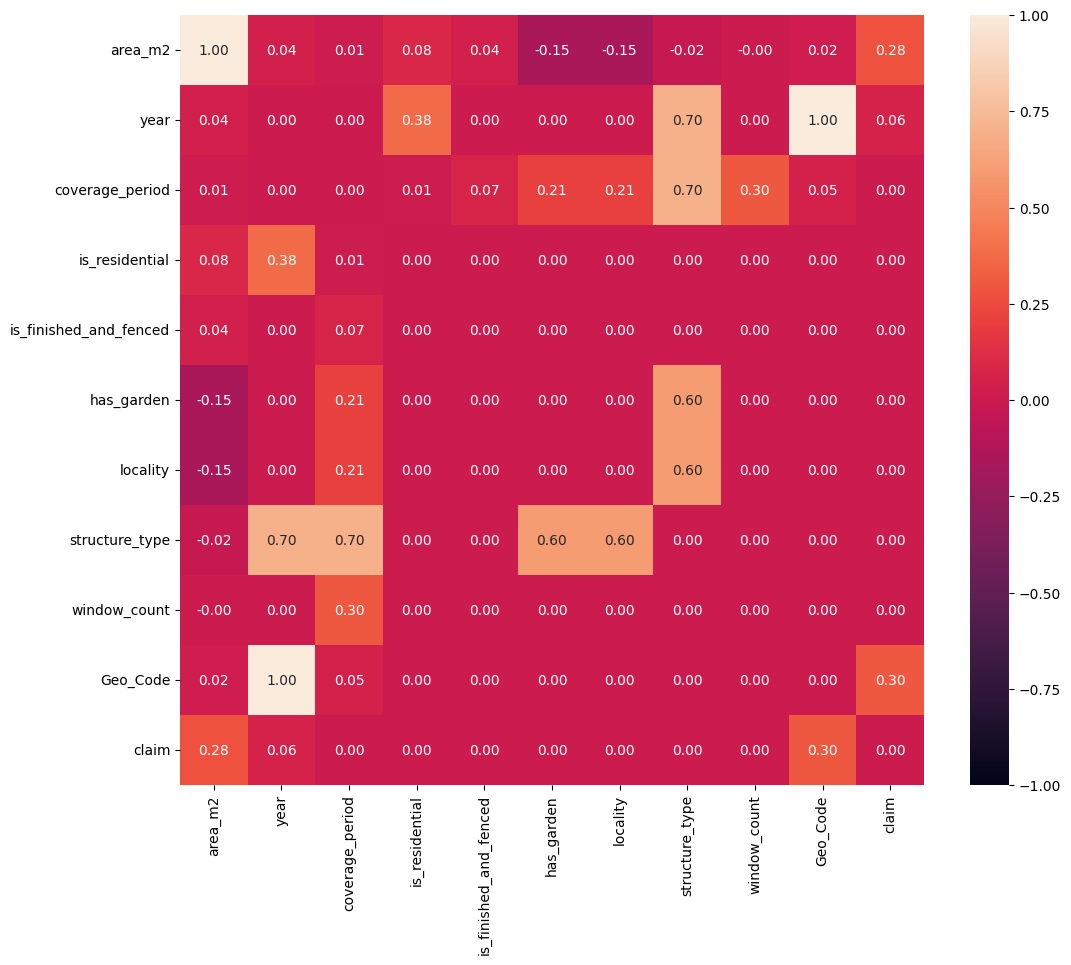

In [78]:
# Fonction pour calculer les corrélations
def compute_correlation(df, l_num, l_discret):
    cols = l_num + l_discret
    n = len(cols)
    corr_matrix = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)

    for i in range(n):
        for j in range(i, n):
            col1, col2 = cols[i], cols[j]

            if col1 in l_num and col2 in l_num:
                # Pearson correlation
                corr, _ = pearsonr(df[col1], df[col2])
            elif col1 in l_discret and col2 in l_discret:
                # Chi2 correlation
                contingency_table = pd.crosstab(df[col1], df[col2])
                _, corr, _, _ = chi2_contingency(contingency_table)
                #corr, _, _, _ = chi2_contingency(contingency_table)

                #corr = 1 - corr / contingency_table.size  # Normalized for interpretation
            else:
                # Spearman correlation
                corr, _ = spearmanr(df[col1], df[col2])

            corr_matrix.loc[col1, col2] = np.round(corr,2)
            corr_matrix.loc[col2, col1] = np.round(corr,2)  # Symmetric matrix

    return corr_matrix

# Calculer la matrice de corrélation
plt.figure(figsize=(12, 10))
sns.heatmap(compute_correlation(train.dropna(), l_num, l_discret), vmax=1, vmin=-1, annot=True, fmt=".2f")
plt.show()

In [79]:
#categorie /categorie ::::claim/les categories 
#on enleve year et geo code car ils sont categorielles
#donc on enleve les categorielles qui ont valeur >0.05 selon chi carré

In [80]:
train =supprimer_colonnes(train, ["Geo_Code","year"])
train
l_discret.remove('Geo_Code')
l_discret.remove('year')



In [81]:
train.isna().sum()

coverage_period            0
is_residential             0
is_finished_and_fenced     0
has_garden                 0
locality                   0
area_m2                   77
structure_type             0
window_count               0
claim                      0
dtype: int64

**<span style="color:blue;">VISUALISATION ET TRAITEMENT DE NANS ET OUTLIERS DE 'area_m2'</span>**

<Axes: ylabel='area_m2'>

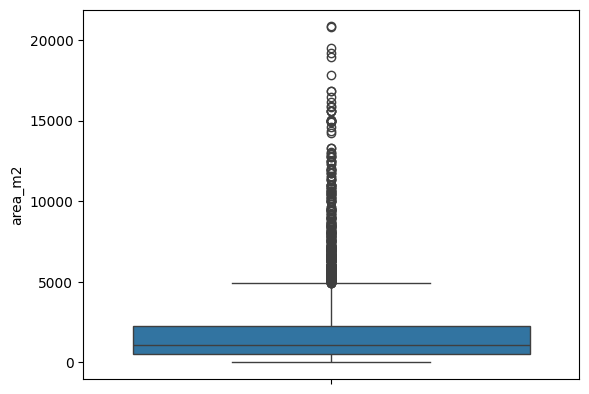

In [82]:
sns.boxplot(train['area_m2'])


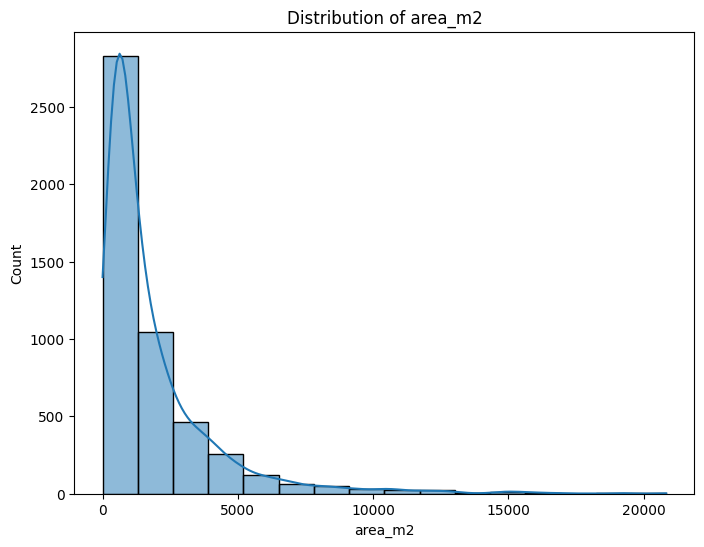

In [83]:
def plot_kde(df):
    numeric_cols = l_num
    
    for col in numeric_cols:
        plt.figure(figsize=(8, 6))
        sns.histplot(data=df,bins=16, x=col, kde=True)
        plt.title(f'Distribution of {col}')
        plt.show()

# Example usage:
plot_kde(train)

In [84]:
#Le QuantileTransformer ajuste la forme de la distribution.
      #Idée : on prend les valeurs de la colonne et on les remplace par leurs quantiles.
      #Résultat : la nouvelle colonne suit une distribution uniforme (entre 0 et 1).

#Le MinMaxScaler ajuste l’échelle (bornes min/max).
      #Idée : prendre les valeurs et les remettre entre 0 et 1 (ou un autre intervalle) :::données normalisées

In [85]:
#IterativeImputer :essayer de prédire les valeurs manquantes d’une colonne en utilisant les autres colonnes comme features, comme dans un petit modèle de régression
#from sklearn.experimental import enable_iterative_imputer  
#from sklearn.impute import IterativeImputer
#from sklearn.preprocessing import QuantileTransformer, MinMaxScaler

#def area_trait(df, enc, scaler, imputer):
 #   df[['area_m2']] = scaler.fit_transform(
  #      enc.fit_transform(df.loc[:, ['area_m2']])
   # )
    #df[['area_m2']] = imputer.fit_transform(df.loc[:, ['area_m2']])

#enc = QuantileTransformer(output_distribution="uniform")
#scaler = MinMaxScaler()

#  IterativeImputer
#imputer = IterativeImputer(random_state=0)

#area_trait(train, enc, scaler, imputer)

# par example 10 itérations :

#À chaque itération, les imputations sont raffinées, parce que les colonnes utilisées  sont elles-mêmes mieux imputées.

#Après quelques itérations, les valeurs “stabilisent” → on considère que l’imputation est convergée.


In [86]:

# Version alternative avec highlight simple
def get_conflicting_lines(df, target='claim'):
    """
    Version simplifiée : retourne uniquement les lignes conflictuelles
    avec leur groupe.
    """
    cols = [c for c in df.columns if c != target]
    
    # Créer un groupe par combinaison de features
    df_temp = df.copy()
    df_temp['_group'] = df_temp.groupby(cols).ngroup()
    
    # Identifier les groupes conflictuels
    conflict_groups = df_temp.groupby('_group')[target].filter(lambda x: x.nunique() > 1)
    conflict_indices = conflict_groups.index
    
    # Récupérer toutes les lignes de ces groupes
    df_conflicts = df_temp.loc[conflict_indices].copy()
    
    # Trier et réinitialiser l'index
    df_conflicts = df_conflicts.sort_values('_group').reset_index(drop=True)
    
    # Ajouter des métadonnées
    df_conflicts['_conflict_group'] = df_conflicts['_group']
    df_conflicts['_conflict_size'] = df_conflicts.groupby('_group')['_group'].transform('count')
    
    return df_conflicts
df_conf=get_conflicting_lines(train)
df_conf

,coverage_period,is_residential,is_finished_and_fenced,has_garden,locality,area_m2,structure_type,window_count,claim,_group,_conflict_group,_conflict_size
0,0.5,0.0,N/V,V,U,400.0,Ordinary,without,non,32.0,32.0,2
1,0.5,0.0,N/V,V,U,400.0,Ordinary,without,oui,32.0,32.0,2
2,0.5,0.0,N/V,V,U,600.0,Non-combustible,without,non,59.0,59.0,3
3,0.5,0.0,N/V,V,U,600.0,Non-combustible,without,oui,59.0,59.0,3
4,0.5,0.0,N/V,V,U,600.0,Non-combustible,without,non,59.0,59.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
676,1.0,1.0,V/V,V,U,1400.0,Wood-framed,without,oui,3824.0,3824.0,3
677,1.0,1.0,V/V,V,U,1400.0,Wood-framed,without,non,3824.0,3824.0,3
678,1.0,1.0,V/V,V,U,1400.0,Wood-framed,without,non,3824.0,3824.0,3
679,1.0,1.0,V/V,V,U,1428.0,Ordinary,without,oui,3825.0,3825.0,2


In [87]:
def remove_conflicting_duplicates(df, target='claim'):
    """
    Supprime les lignes où les features sont identiques mais 'claim' est différent.
    """
    cols = [c for c in df.columns if c != target]
    
    # Créer un groupe par combinaison de features
    df_temp = df.copy()
    df_temp['_group'] = df_temp.groupby(cols).ngroup()
    
    # Identifier les groupes où 'claim' n'est pas unique
    conflict_groups = df_temp.groupby('_group')[target].nunique()
    conflict_groups = conflict_groups[conflict_groups > 1].index
    
    # Masque des lignes à supprimer
    mask = df_temp['_group'].isin(conflict_groups)
    
    print(f"Groupes en conflit : {len(conflict_groups)}")
    print(f"Lignes supprimées : {mask.sum()}")
    
    # Nettoyer
    df_clean = df_temp[~mask].drop(columns='_group')
    
    print(f"Lignes avant : {len(df)} → après : {len(df_clean)}")
    
    return df_clean

# Utilisation
train = remove_conflicting_duplicates(train, 'claim').reset_index(drop=True)
train

Groupes en conflit : 235
Lignes supprimées : 681
Lignes avant : 5008 → après : 4327


,coverage_period,is_residential,is_finished_and_fenced,has_garden,locality,area_m2,structure_type,window_count,claim
0,1.0,1.0,N/V,V,U,1240.0,Wood-framed,without,non
1,1.0,1.0,V/N,O,R,4984.0,Non-combustible,4,oui
2,0.5,0.0,N/V,V,U,600.0,Wood-framed,without,oui
3,0.5,0.0,N/V,V,U,2675.0,Ordinary,without,non
4,1.0,1.0,V/N,O,R,2500.0,Non-combustible,2,non
...,...,...,...,...,...,...,...,...,...
4322,0.5,0.0,N/V,V,U,300.0,Non-combustible,without,non
4323,0.5,0.0,N/V,V,U,173.0,Non-combustible,without,non
4324,0.5,0.0,V/N,O,R,1000.0,Fire-resistive,4,non
4325,0.5,0.0,V/N,O,R,536.0,Fire-resistive,4,non


In [88]:
def show_duplicates(df, target='claim'):
    """
    Affiche toutes les lignes dupliquées en ignorant la colonne cible.
    """
    cols = [c for c in df.columns if c != target]
    duplicated = df.duplicated(subset=cols, keep=False)
    
    print(f"Nombre de lignes dupliquées (hors '{target}') : {duplicated.sum()}")
    
    if duplicated.any():
        print("\nLignes dupliquées :")
        display(df[duplicated].sort_values(by=cols))
    else:
        print("Aucun doublon trouvé.")
    
    

# Utilisation
show_duplicates(train, 'claim')


Nombre de lignes dupliquées (hors 'claim') : 1133

Lignes dupliquées :


,coverage_period,is_residential,is_finished_and_fenced,has_garden,locality,area_m2,structure_type,window_count,claim
1433,0.5,0.0,N/V,V,U,150.0,Non-combustible,without,non
3726,0.5,0.0,N/V,V,U,150.0,Non-combustible,without,non
274,0.5,0.0,N/V,V,U,200.0,Fire-resistive,without,non
2580,0.5,0.0,N/V,V,U,200.0,Fire-resistive,without,non
2681,0.5,0.0,N/V,V,U,300.0,Non-combustible,without,non
...,...,...,...,...,...,...,...,...,...
630,1.0,1.0,V/V,V,U,NaN,Ordinary,without,oui
1814,1.0,1.0,V/V,V,U,NaN,Ordinary,without,oui
2256,1.0,1.0,V/V,V,U,NaN,Ordinary,without,non
2419,1.0,1.0,V/V,V,U,NaN,Ordinary,without,oui


In [89]:
def show_duplicate_counts(df):
    """
    Affiche, pour chaque groupe de lignes dupliquées restantes (après suppression des conflits),
    le nombre de doublons (combien de fois chaque ligne apparaît).
    """
    cols = df.columns.tolist()
    
    # Créer un groupe par combinaison de features
    df_temp = df.copy()
    df_temp['_group'] = df_temp.groupby(cols).ngroup()
    
    # Compter la taille de chaque groupe
    group_counts = df_temp['_group'].value_counts()
    
    # Garder seulement les groupes avec 2+ occurrences
    duplicated_groups = group_counts[group_counts >= 2]
    
    if duplicated_groups.empty:
        print("Aucun doublon restant (toutes les lignes sont uniques).")
        return
    
    print(f"{len(duplicated_groups)} groupes dupliqués restants.\n")
    print("Nombre de doublons par groupe (trié décroissant) :\n")
    
    # Afficher chaque groupe avec son nombre
    for group_id, count in duplicated_groups.items():
        # Récupérer une ligne du groupe pour afficher les valeurs
        sample_row = df_temp[df_temp['_group'] == group_id].iloc[0]
        print(f"--- Groupe {group_id} : {count} doublons ---")
        print(sample_row[cols].to_string())
        print("-" * 60)
    
    if len(duplicated_groups) > 20:
        print(f"... et {len(duplicated_groups) - 20} autres groupes.")

# === Utilisation ===
show_duplicate_counts(train)

449 groupes dupliqués restants.

Nombre de doublons par groupe (trié décroissant) :

--- Groupe 1232.0 : 8 doublons ---
coverage_period                       1.0
is_residential                        0.0
is_finished_and_fenced                N/V
has_garden                              V
locality                                U
area_m2                             500.0
structure_type            Non-combustible
window_count                      without
claim                                 non
------------------------------------------------------------
--- Groupe 2495.0 : 7 doublons ---
coverage_period                       1.0
is_residential                        0.0
is_finished_and_fenced                V/V
has_garden                              V
locality                                U
area_m2                             600.0
structure_type            Non-combustible
window_count                      without
claim                                 non
----------------------------

In [90]:
def count_duplicates_by_claim(df, target='claim'):
    """
    Calcule le nombre de lignes dupliquées (hors colonne cible)
    réparties par valeur de la colonne target (ex: claim = oui / non).
    """
    # Colonnes sans la cible
    cols = [c for c in df.columns if c != target]
    
    # Détection des doublons
    duplicated_mask = df.duplicated(subset=cols, keep=False)
    
    # Filtrer uniquement les doublons
    duplicated_df = df[duplicated_mask]
    
    if duplicated_df.empty:
        print("Aucun doublon trouvé.")
        return
    
    # Comptage par classe
    counts = duplicated_df[target].value_counts().sort_index()
    
    print("📊 Nombre de doublons par valeur de 'claim' :\n")
    for value, count in counts.items():
        print(f" - {value} : {count}")
    
    return counts
dup_by_claim = count_duplicates_by_claim(train, target='claim')


📊 Nombre de doublons par valeur de 'claim' :

 - non : 1032
 - oui : 101


In [91]:
train=train.drop_duplicates()

In [92]:
class AreaTrait:

    def __init__(self):
        self.enc = QuantileTransformer(output_distribution="uniform")
        self.scaler = MinMaxScaler()
        self.imputer = SimpleImputer(strategy="median")
       
       
    def fit(self, X):
        col = X[['area_m2']].copy()

        # fit sur chaque étape
        self.enc.fit(col)
        col = self.enc.transform(col)

        self.scaler.fit(col)
        col = self.scaler.transform(col)

        self.imputer.fit(col)

        return self   # pour permettre .fit().transform()

    def transform(self, X):
        X = X.copy()
        col = X[['area_m2']]

        col = self.enc.transform(col)
        col = self.scaler.transform(col)
        col = self.imputer.transform(col)

        X['area_m2'] = col
        return X

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)
    
area_processor = AreaTrait()

train = area_processor.fit_transform(train)





In [93]:
train

,coverage_period,is_residential,is_finished_and_fenced,has_garden,locality,area_m2,structure_type,window_count,claim
0,1.0,1.0,N/V,V,U,0.509640,Wood-framed,without,non
1,1.0,1.0,V/N,O,R,0.912160,Non-combustible,4,oui
2,0.5,0.0,N/V,V,U,0.263764,Wood-framed,without,oui
3,0.5,0.0,N/V,V,U,0.761432,Ordinary,without,non
4,1.0,1.0,V/N,O,R,0.746246,Non-combustible,2,non
...,...,...,...,...,...,...,...,...,...
4321,1.0,1.0,V/V,V,U,0.346346,Ordinary,without,non
4323,0.5,0.0,N/V,V,U,0.021972,Non-combustible,without,non
4324,0.5,0.0,V/N,O,R,0.431431,Fire-resistive,4,non
4325,0.5,0.0,V/N,O,R,0.235675,Fire-resistive,4,non


<Axes: xlabel='area_m2', ylabel='Count'>

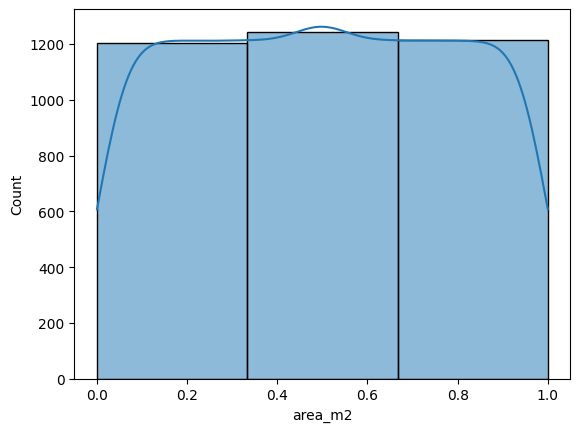

In [94]:
sns.histplot(data=train,bins=3, x='area_m2', kde=True)

<Axes: ylabel='area_m2'>

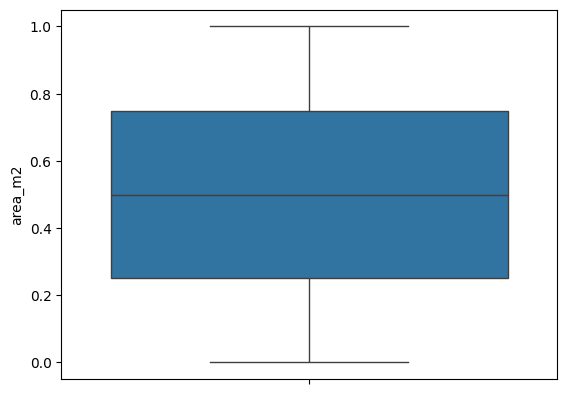

In [95]:
sns.boxplot(train['area_m2'])


**<span style="color:blue;">TRAITEMENT DES DUPLICATA</span>**

In [96]:
train.duplicated().sum()


np.int64(5)

**<span style="color:blue;">TRAITEMENT DE 'is_finished_and_fenced'</span>**

In [97]:
def split(df):
    # Split la colonne en deux nouvelles colonnes temporaires
    df[['is_finished', 'is_fenced']] = df['is_finished_and_fenced'].str.split('/', expand=True)
    
    # Sauvegarder les séries
    is_finished = df['is_finished']
    is_fenced = df['is_fenced']
    
    # Supprimer les colonnes temporaires
    df = supprimer_colonnes(df,['is_finished', 'is_fenced', 'is_finished_and_fenced'])
    
    # Insérer aux positions 3 et 4
    df.insert(2, 'is_finished', is_finished)
    df.insert(3, 'is_fenced', is_fenced)

    

    
    return df
l_discret.remove('is_finished_and_fenced')
l_discret.append('is_finished')
l_discret.append(' is_fenced')
train = split(train)
train



,coverage_period,is_residential,is_finished,is_fenced,has_garden,locality,area_m2,structure_type,window_count,claim
0,1.0,1.0,N,V,V,U,0.509640,Wood-framed,without,non
1,1.0,1.0,V,N,O,R,0.912160,Non-combustible,4,oui
2,0.5,0.0,N,V,V,U,0.263764,Wood-framed,without,oui
3,0.5,0.0,N,V,V,U,0.761432,Ordinary,without,non
4,1.0,1.0,V,N,O,R,0.746246,Non-combustible,2,non
...,...,...,...,...,...,...,...,...,...,...
4321,1.0,1.0,V,V,V,U,0.346346,Ordinary,without,non
4323,0.5,0.0,N,V,V,U,0.021972,Non-combustible,without,non
4324,0.5,0.0,V,N,O,R,0.431431,Fire-resistive,4,non
4325,0.5,0.0,V,N,O,R,0.235675,Fire-resistive,4,non


**<span style="color:blue;">TRAITEMENT DE  'Window_count'</span>**

In [98]:
train['window_count'].value_counts()

window_count
without    1705
4           489
3           422
5           353
2           196
6           188
7           128
8            65
1            43
>=10         41
9            29
Name: count, dtype: int64

In [99]:
def trait_number_windows(df):
    df=df.replace('without',0)
    df=df.replace('>=10',10)
    df['window_count']=df['window_count'].astype('int32')
    return df

train=trait_number_windows(train)
train['window_count'].value_counts()


window_count
0     1705
4      489
3      422
5      353
2      196
6      188
7      128
8       65
1       43
10      41
9       29
Name: count, dtype: int64

In [100]:
train.isna().sum()

coverage_period    0
is_residential     0
is_finished        0
is_fenced          0
has_garden         0
locality           0
area_m2            0
structure_type     0
window_count       0
claim              0
dtype: int64

In [101]:
train.dtypes

coverage_period    float64
is_residential     float64
is_finished         object
is_fenced           object
has_garden          object
locality            object
area_m2            float64
structure_type      object
window_count         int32
claim               object
dtype: object

In [102]:
print(l_discret)

['coverage_period', 'is_residential', 'has_garden', 'locality', 'structure_type', 'window_count', 'claim', 'is_finished', ' is_fenced']


**<span style="color:blue;">VISUALISTAION</span>**

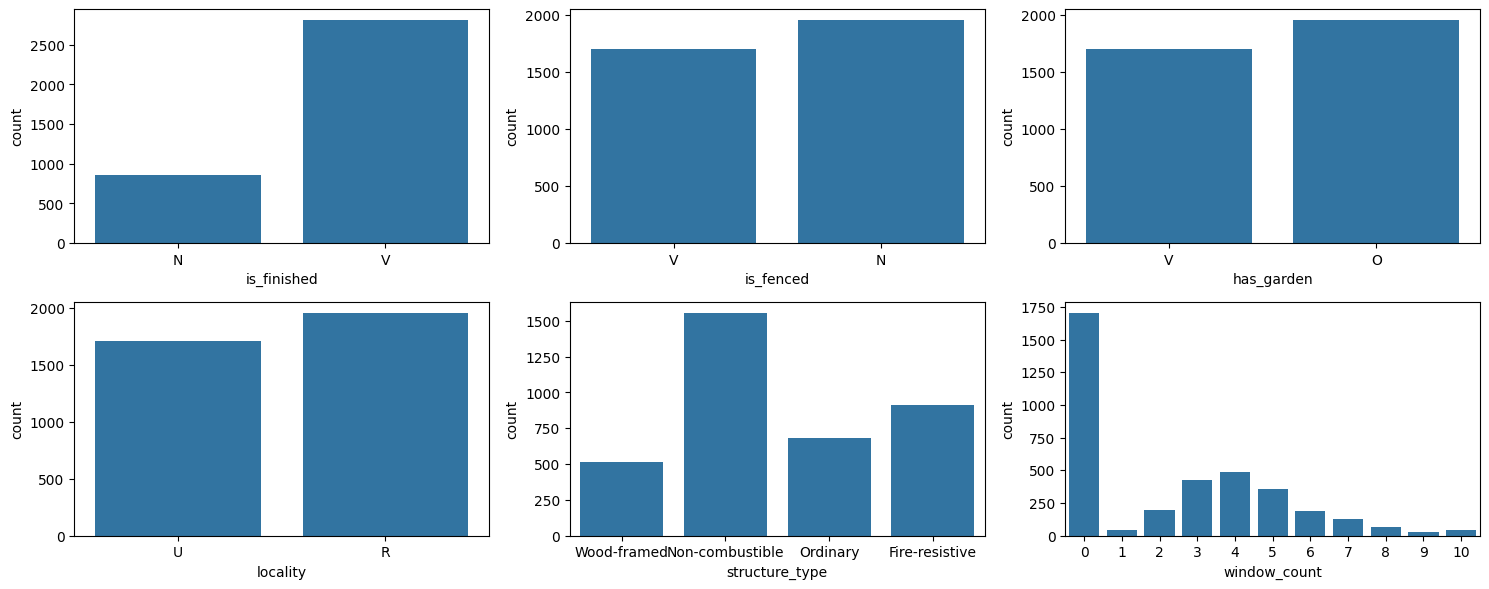

In [103]:
L=[ 'is_finished', 'is_fenced', 'has_garden', 'locality', 'structure_type', 'window_count']
plt.figure(figsize=(15,6))
for i in range(len(L)):
    plt.subplot(2,3,i+1)
    sns.countplot(data=train, x=L[i])
plt.tight_layout()
plt.show()

**<span style="color:blue;">TRANSFORMATION</span>**

In [104]:
# Cache global pour stocker les intervalles de discrétisation
"""_bins_cache = {}

def discretiser(df, colonne, n_bins=5, mode="train"):
    df_out = df.copy()

    # --- TRAIN : calcul des bins ---
    if mode == "train":
        # créer les bornes
        min_val = df_out[colonne].min()
        max_val = df_out[colonne].max()
        bins = np.linspace(min_val, max_val, n_bins + 1)

        # stocker les bins
        _bins_cache[colonne] = bins

    # --- TEST : utiliser les bins existants ---
    elif mode == "test":
        if colonne not in _bins_cache:
            raise ValueError(f"Les bins de '{colonne}' n'ont pas encore été définis (mode train manquant).")
        bins = _bins_cache[colonne]

    else:
        raise ValueError("mode doit être 'train' ou 'test'.")

    # --- Discrétisation ---
    labels = [
        f"{colonne}_{round(bins[i],1)}-{round(bins[i+1],1)}"
        for i in range(len(bins)-1)
    ]

    df_out[colonne + "_discret"] = pd.cut(
        df_out[colonne],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    return df_out
train = discretiser(train, 'area_m2', n_bins=5, mode='train')
train
"""

'_bins_cache = {}\n\ndef discretiser(df, colonne, n_bins=5, mode="train"):\n    df_out = df.copy()\n\n    # --- TRAIN : calcul des bins ---\n    if mode == "train":\n        # créer les bornes\n        min_val = df_out[colonne].min()\n        max_val = df_out[colonne].max()\n        bins = np.linspace(min_val, max_val, n_bins + 1)\n\n        # stocker les bins\n        _bins_cache[colonne] = bins\n\n    # --- TEST : utiliser les bins existants ---\n    elif mode == "test":\n        if colonne not in _bins_cache:\n            raise ValueError(f"Les bins de \'{colonne}\' n\'ont pas encore été définis (mode train manquant).")\n        bins = _bins_cache[colonne]\n\n    else:\n        raise ValueError("mode doit être \'train\' ou \'test\'.")\n\n    # --- Discrétisation ---\n    labels = [\n        f"{colonne}_{round(bins[i],1)}-{round(bins[i+1],1)}"\n        for i in range(len(bins)-1)\n    ]\n\n    df_out[colonne + "_discret"] = pd.cut(\n        df_out[colonne],\n        bins=bins,\n     

In [105]:
train

,coverage_period,is_residential,is_finished,is_fenced,has_garden,locality,area_m2,structure_type,window_count,claim
0,1.0,1.0,N,V,V,U,0.509640,Wood-framed,0,non
1,1.0,1.0,V,N,O,R,0.912160,Non-combustible,4,oui
2,0.5,0.0,N,V,V,U,0.263764,Wood-framed,0,oui
3,0.5,0.0,N,V,V,U,0.761432,Ordinary,0,non
4,1.0,1.0,V,N,O,R,0.746246,Non-combustible,2,non
...,...,...,...,...,...,...,...,...,...,...
4321,1.0,1.0,V,V,V,U,0.346346,Ordinary,0,non
4323,0.5,0.0,N,V,V,U,0.021972,Non-combustible,0,non
4324,0.5,0.0,V,N,O,R,0.431431,Fire-resistive,4,non
4325,0.5,0.0,V,N,O,R,0.235675,Fire-resistive,4,non


In [106]:
L

['is_finished',
 'is_fenced',
 'has_garden',
 'locality',
 'structure_type',
 'window_count']

In [107]:
class OneHotencoder:

    def __init__(self, cols):
        self.cols = cols               # colonnes à encoder
        self.enc = OneHotEncoder(sparse_output=False)

    def fit(self, df):
        """Fit sur le train uniquement."""
        df_sub = df[self.cols]

        self.enc.fit(df_sub)

        # on stocke les noms des features créées
        self.feature_names = self.enc.get_feature_names_out(self.cols)

        return self   # permet .fit().transform()

    def transform(self, df):

        df_result = df.copy()

        # --- Sauvegarde de la colonne 'claim' si elle existe ---
        claim_exists = "claim" in df_result.columns
        if claim_exists:
            claim_col = df_result["claim"].copy()

        # sous-DF
        df_sub = df_result[self.cols]

        # encodage
        encoded = self.enc.transform(df_sub)

        # conversion
        df_encoded = pd.DataFrame(encoded, columns=self.feature_names, index=df.index)

        # retirer les colonnes d’origine
        df_result = df_result.drop(columns=self.cols)

        # concaténer
        df_result = pd.concat([df_result, df_encoded], axis=1)

        # --- Remettre claim à la fin ---
        if claim_exists:
            df_result = df_result.drop(columns=["claim"])
            df_result["claim"] = claim_col

        return df_result

    def fit_transform(self, df):
        self.fit(df)
        return self.transform(df)
    
encoder = OneHotencoder(cols=L)

train = encoder.fit_transform(train)
train


,coverage_period,is_residential,area_m2,is_finished_N,is_finished_V,is_fenced_N,is_fenced_V,has_garden_O,has_garden_V,locality_R,...,window_count_2,window_count_3,window_count_4,window_count_5,window_count_6,window_count_7,window_count_8,window_count_9,window_count_10,claim
0,1.0,1.0,0.509640,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,non
1,1.0,1.0,0.912160,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,oui
2,0.5,0.0,0.263764,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,oui
3,0.5,0.0,0.761432,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,non
4,1.0,1.0,0.746246,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,non
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4321,1.0,1.0,0.346346,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,non
4323,0.5,0.0,0.021972,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,non
4324,0.5,0.0,0.431431,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,non
4325,0.5,0.0,0.235675,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,non


In [108]:
# Utilisation de base
"""df_sans_redondants, supprimees = supprimer_redondants_avance(
    train, 
    confidence_seuil=0.7, 
    lift_seuil=1.1,
    target='class'  # optionnel
)
print(supprimees)

print(f"DataFrame réduit: {df_sans_redondants.shape}")"""

'df_sans_redondants, supprimees = supprimer_redondants_avance(\n    train, \n    confidence_seuil=0.7, \n    lift_seuil=1.1,\n    target=\'class\'  # optionnel\n)\nprint(supprimees)\n\nprint(f"DataFrame réduit: {df_sans_redondants.shape}")'

In [109]:
"""train=df_sans_redondants
train"""

'train=df_sans_redondants\ntrain'

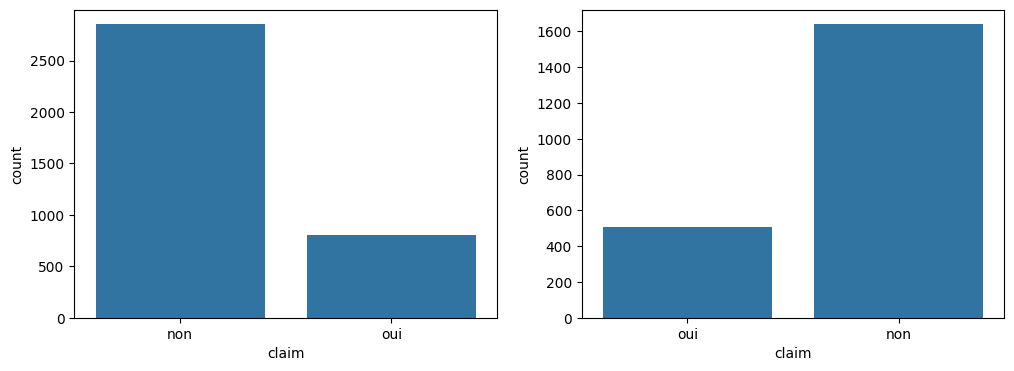

claim
non    2853
oui     806
Name: count, dtype: int64


In [110]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.countplot(train, x="claim")
plt.subplot(1,2,2)
sns.countplot(test, x="claim")
plt.show()

print(train['claim'].value_counts())# Imbalanced Data!!

**<span style="color:blue;">TRAITEMENT DU TEST</span>**

In [111]:
test.describe(include="all")

,policy_id,year,coverage_period,is_residential,is_finished_and_fenced,has_garden,locality,area_m2,structure_type,window_count,risk_score,Geo_Code,claim
count,2147,2147.000000,2147.000000,2147.000000,2147,2144,2147,2118.000000,2147,2147,2147.000000,2118,2147
unique,2147,NaN,NaN,NaN,4,2,2,NaN,4,11,NaN,714,2
top,H3733,NaN,NaN,NaN,V/N,V,U,NaN,Non-combustible,without,NaN,6088,non
freq,1,NaN,NaN,NaN,1071,1074,1074,NaN,995,1074,NaN,41,1639
mean,NaN,2013.691197,0.876805,0.315789,NaN,NaN,NaN,1899.700189,NaN,NaN,0.500186,NaN,NaN
std,NaN,1.385631,0.215504,0.464938,NaN,NaN,NaN,2304.300053,NaN,NaN,0.232729,NaN,NaN
min,NaN,2012.000000,0.500000,0.000000,NaN,NaN,NaN,10.000000,NaN,NaN,0.100000,NaN,NaN
25%,NaN,2012.000000,1.000000,0.000000,NaN,NaN,NaN,535.500000,NaN,NaN,0.290000,NaN,NaN
50%,NaN,2013.000000,1.000000,0.000000,NaN,NaN,NaN,1100.000000,NaN,NaN,0.490000,NaN,NaN
75%,NaN,2015.000000,1.000000,1.000000,NaN,NaN,NaN,2300.000000,NaN,NaN,0.710000,NaN,NaN


In [112]:
test

,policy_id,year,coverage_period,is_residential,is_finished_and_fenced,has_garden,locality,area_m2,structure_type,window_count,risk_score,Geo_Code,claim
0,H3733,2013,1.0,0,V/V,V,U,3760.0,Fire-resistive,without,0.72,43157,oui
1,H16909,2015,1.0,0,V/N,O,R,1452.0,Fire-resistive,5,0.45,58194,non
2,H16867,2013,1.0,1,V/N,O,R,1944.0,Ordinary,6,0.79,92050,oui
3,H14813,2015,1.0,0,N/V,V,U,2270.0,Non-combustible,without,0.66,13209,oui
4,H3728,2016,0.5,0,V/N,O,R,2976.0,Fire-resistive,9,0.18,5177,non
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2142,H19924,2016,0.5,1,V/N,O,R,862.0,Wood-framed,2,0.71,6159,non
2143,H17249,2012,1.0,0,V/V,V,U,NaN,Non-combustible,without,0.75,NaN,non
2144,H18804,2014,1.0,0,V/N,O,R,730.0,Non-combustible,3,0.35,69027,non
2145,H12650,2014,1.0,1,N/V,V,U,568.0,Non-combustible,without,0.84,69091,oui


In [113]:
test.isnull().sum()

policy_id                  0
year                       0
coverage_period            0
is_residential             0
is_finished_and_fenced     0
has_garden                 3
locality                   0
area_m2                   29
structure_type             0
window_count               0
risk_score                 0
Geo_Code                  29
claim                      0
dtype: int64

In [114]:
test=supprimer_colonnes(test, ['policy_id','risk_score'])
test.dropna(how="all",inplace=True,ignore_index=True)
test=test.dropna(subset=["has_garden"],how="any",ignore_index=True)
test =split(test)
test =supprimer_colonnes(test, ["Geo_Code","year"])
df_conf_test=get_conflicting_lines(test)
df_conf_test

,coverage_period,is_finished,is_fenced,is_residential,has_garden,locality,area_m2,structure_type,window_count,claim,_group,_conflict_group,_conflict_size
0,0.5,V,N,0,O,R,3700.0,Fire-resistive,6,non,262.0,262.0,2
1,0.5,V,N,0,O,R,3700.0,Fire-resistive,6,oui,262.0,262.0,2
2,0.5,V,N,0,O,R,5300.0,Ordinary,5,oui,273.0,273.0,2
3,0.5,V,N,0,O,R,5300.0,Ordinary,5,non,273.0,273.0,2
4,0.5,V,V,0,V,U,550.0,Non-combustible,without,non,405.0,405.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,1.0,V,V,0,V,U,2041.0,Fire-resistive,without,non,1757.0,1757.0,3
134,1.0,V,V,0,V,U,2100.0,Non-combustible,without,non,1760.0,1760.0,2
135,1.0,V,V,0,V,U,2100.0,Non-combustible,without,oui,1760.0,1760.0,2
136,1.0,V,V,0,V,U,3700.0,Non-combustible,without,oui,1787.0,1787.0,2


In [115]:

test = remove_conflicting_duplicates(test, 'claim').reset_index(drop=True)
test=test.drop_duplicates()
test=area_processor.transform(test)
test=trait_number_windows(test)
"""test = discretiser(
    test, 
    colonne='area_m2',
    mode='test'
)"""

test = encoder.transform(test)
test


Groupes en conflit : 56
Lignes supprimées : 138
Lignes avant : 2144 → après : 2006


,coverage_period,is_residential,area_m2,is_finished_N,is_finished_V,is_fenced_N,is_fenced_V,has_garden_O,has_garden_V,locality_R,...,window_count_2,window_count_3,window_count_4,window_count_5,window_count_6,window_count_7,window_count_8,window_count_9,window_count_10,claim
0,1.0,0,0.851774,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,oui
1,1.0,0,0.564965,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,non
2,1.0,1,0.658629,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,oui
3,1.0,0,0.716630,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,oui
4,0.5,0,0.794593,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,non
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999,1.0,0,0.974520,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,non
2001,0.5,1,0.380447,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,non
2003,1.0,0,0.323824,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,non
2004,1.0,1,0.249669,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,oui


In [116]:
list(train)==list(test)

True

**<span style="color:red;">Partie2:</span>**

In [117]:
X_train=train.iloc[:,:-1]
y_train=train.iloc[:,-1]

X_test=test.iloc[:,:-1]
y_test =test.iloc[:,-1]
def encode_labels_basic(y_train, y_test):
    
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_test_encoded = le.transform(y_test)
    
    print(f"✓ Labels encodés: 'non'->{le.transform(['non'])[0]}, 'oui'->{le.transform(['oui'])[0]}")
    
    return y_train_encoded, y_test_encoded

# Utilisation de la version basic
y_train, y_test= encode_labels_basic(y_train, y_test)

✓ Labels encodés: 'non'->0, 'oui'->1


**<span style="color:blue;">Importance des features </span>**

In [118]:
"""from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np





# Baseline model
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Permutation importance
perm = permutation_importance(
    rf,
    X_train,
    y_train,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": perm.importances_mean
}).sort_values(by="importance", ascending=False)

print(importances)
threshold = importances["importance"].mean()

selected_features = importances[
    importances["importance"] > threshold
]["feature"].tolist()

print("Selected features :", selected_features)
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]"""



'from sklearn.ensemble import RandomForestClassifier\nfrom sklearn.inspection import permutation_importance\nimport pandas as pd\nimport numpy as np\n\n\n\n\n\n# Baseline model\nrf = RandomForestClassifier(\n    n_estimators=300,\n    max_depth=None,\n    random_state=42,\n    n_jobs=-1\n)\nrf.fit(X_train, y_train)\n\n# Permutation importance\nperm = permutation_importance(\n    rf,\n    X_train,\n    y_train,\n    n_repeats=10,\n    random_state=42,\n    n_jobs=-1\n)\n\nimportances = pd.DataFrame({\n    "feature": X_train.columns,\n    "importance": perm.importances_mean\n}).sort_values(by="importance", ascending=False)\n\nprint(importances)\nthreshold = importances["importance"].mean()\n\nselected_features = importances[\n    importances["importance"] > threshold\n]["feature"].tolist()\n\nprint("Selected features :", selected_features)\nX_train_sel = X_train[selected_features]\nX_test_sel = X_test[selected_features]'

In [119]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Initialiser le classifieur
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Définir la grille des hyperparamètres
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# GridSearchCV pour trouver les meilleurs paramètres
gs = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# Entraînement
gs.fit(X_train, y_train)

# Affichage des résultats
print("✅ Meilleurs hyperparamètres :", gs.best_params_)
print("✅ Meilleur score F1-weighted CV :", gs.best_score_)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
✅ Meilleurs hyperparamètres : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
✅ Meilleur score F1-weighted CV : 0.7488006181663931


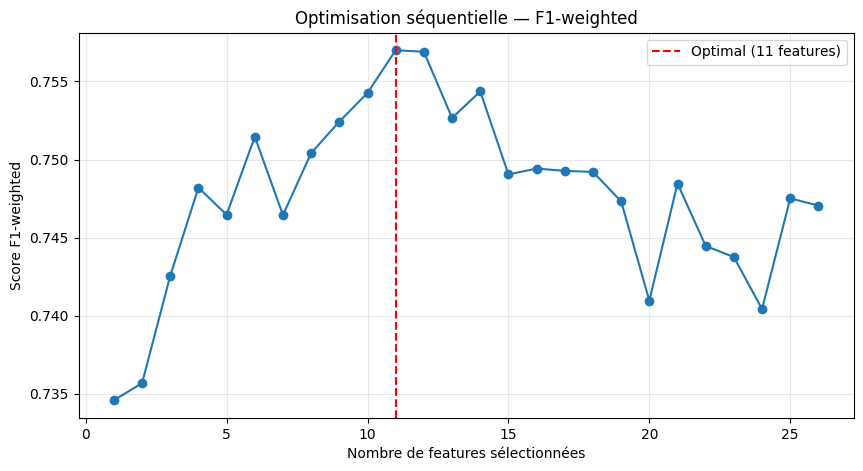

✅ Nombre optimal de features : 11
✅ Meilleur F1-weighted : 0.7570
✅ Features optimales :
  - area_m2
  - coverage_period
  - is_residential
  - structure_type_Wood-framed
  - structure_type_Non-combustible
  - window_count_7
  - structure_type_Fire-resistive
  - structure_type_Ordinary
  - window_count_5
  - window_count_3
  - window_count_10


In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

def plot_sequential_f1_optimal_with_best_rf_noCV(X, y, best_rf, cv_splits=5):

    # Récupérer les importances du modèle optimisé
    importances = best_rf.feature_importances_

    # DataFrame des importances
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # Tri des features selon leur importance
    sorted_features = feature_importance_df['Feature'].values
    scores = []

    # Sélection séquentielle (sans StratifiedKFold)
    for n in range(1, len(sorted_features) + 1):
        selected_features = sorted_features[:n]
        X_subset = X[selected_features].values

        score = cross_val_score(
            best_rf,
            X_subset,
            y,
            cv=cv_splits,              # CV automatique
            scoring='f1_weighted',
            n_jobs=-1
        ).mean()

        scores.append(score)

    # Détection du nombre optimal
    best_idx = np.argmax(scores)
    optimal_features = sorted_features[:best_idx + 1]
    best_score = scores[best_idx]

    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(range(1, len(sorted_features) + 1), scores, marker='o')
    plt.axvline(x=best_idx + 1, color='r', linestyle='--',
                label=f'Optimal ({best_idx+1} features)')
    plt.xlabel("Nombre de features sélectionnées")
    plt.ylabel("Score F1-weighted")
    plt.title("Optimisation séquentielle — F1-weighted")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"✅ Nombre optimal de features : {best_idx+1}")
    print(f"✅ Meilleur F1-weighted : {best_score:.4f}")
    print("✅ Features optimales :")
    for f in optimal_features:
        print(f"  - {f}")

    return feature_importance_df, scores, optimal_features, best_score
best_rf = gs.best_estimator_

feature_importance_df, scores, optimal_features, best_score = plot_sequential_f1_optimal_with_best_rf_noCV(
    X_train, y_train, best_rf
)

In [121]:
X_train_sel = X_train[optimal_features]
X_test_sel = X_test[optimal_features]

In [122]:
from sklearn.model_selection import GridSearchCV


# Grille d’hyperparamètres
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}
rf = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    )
# GridSearch
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1_weighted",     # ou f1, roc_auc
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_sel, y_train)

print("Best Params :", grid.best_params_)
print("Best Score (CV):", grid.best_score_)



Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Params : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Score (CV): 0.7499238901231767


In [123]:
best_model_rf = grid.best_estimator_

# Entraînement final sur 100% du train
best_model_rf.fit(X_train_sel, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [124]:
from sklearn.linear_model import LogisticRegression


# Définir le modèle
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Grille d'hyperparamètres AVEC COMBINAISONS VALIDES
param_grid_log = [
    # Combinaison 1: Penalty l1 avec solver qui le supporte
    {
        'penalty': ['l1'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'saga'],
        'class_weight': [None, 'balanced'],
        'max_iter': [100, 200, 500]
    },
    # Combinaison 2: Penalty l2 avec tous les solvers
    {
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga'],
        'class_weight': [None, 'balanced'],
        'max_iter': [100, 200, 500]
    },
    # Combinaison 3: Penalty elasticnet avec solver saga
    {
        'penalty': ['elasticnet'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['saga'],
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],  # NÉCESSAIRE pour elasticnet
        'class_weight': [None, 'balanced'],
        'max_iter': [100, 200, 500]
    },
    # Combinaison 4: Aucune pénalité (None)
    {
        'penalty': [None],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'newton-cg', 'sag', 'saga'],  # liblinear ne supporte pas None
        'class_weight': [None, 'balanced'],
        'max_iter': [100, 200, 500]
    }
]

# GridSearch
grid_log = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_log,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=1,
    error_score='raise'  # Pour voir les erreurs immédiatement
)

grid_log.fit(X_train_sel, y_train)

print("Best Params Logistic Regression:", grid_log.best_params_)
print("Best Score Logistic Regression (CV):", grid_log.best_score_)


Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Best Params Logistic Regression: {'C': 10, 'class_weight': None, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}
Best Score Logistic Regression (CV): 0.7361086887316928


In [125]:
best_model_log = grid_log.best_estimator_

# Entraînement final
best_model_log.fit(X_train_sel, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


In [126]:
from sklearn.tree import DecisionTreeClassifier

# Définir le modèle
dt = DecisionTreeClassifier(random_state=42)

# Grille d'hyperparamètres
param_grid_dt = {
    'max_depth': [None, 5, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2', 0.5, 0.8],
    'class_weight': [None, 'balanced']
}

# GridSearch
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train_sel, y_train)

print("Best Params Decision Tree:", grid_dt.best_params_)
print("Best Score Decision Tree (CV):", grid_dt.best_score_)


Fitting 5 folds for each of 2400 candidates, totalling 12000 fits
Best Params Decision Tree: {'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 2}
Best Score Decision Tree (CV): 0.7560595493038843


In [127]:
best_model_dt = grid_dt.best_estimator_

# Entraînement final
best_model_dt.fit(X_train_sel, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [128]:
from sklearn.svm import SVC

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

# Modèle et GridSearch
svc_linear = SVC(kernel='linear', random_state=42, class_weight='balanced',probability=True)

# Grille d'hyperparamètres (simplifiée pour la recherche rapide)
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1],
    'class_weight': [None, 'balanced']
}

# HalvingGridSearchCV (beaucoup plus rapide que GridSearchCV)
grid_svc = HalvingGridSearchCV(
    estimator=svc_linear,
    param_grid=param_grid_svm,
    factor=3,                # réduit le nombre de candidats à chaque itération
    scoring='f1_weighted',   # ou 'f1', 'roc_auc', etc.
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Recherche rapide avec HalvingGridSearchCV pour SVM...")
grid_svc.fit(X_train_sel, y_train)


print(f"\nBest Params SVC Linear: {grid_svc.best_params_}")
print(f"Best Score SVC Linear (CV): {grid_svc.best_score_}")

Recherche rapide avec HalvingGridSearchCV pour SVM...
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 135
max_resources_: 3659
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 54
n_resources: 135
Fitting 5 folds for each of 54 candidates, totalling 270 fits
----------
iter: 1
n_candidates: 18
n_resources: 405
Fitting 5 folds for each of 18 candidates, totalling 90 fits
----------
iter: 2
n_candidates: 6
n_resources: 1215
Fitting 5 folds for each of 6 candidates, totalling 30 fits
----------
iter: 3
n_candidates: 2
n_resources: 3645
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Best Params SVC Linear: {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'poly'}
Best Score SVC Linear (CV): 0.7455901116708599


In [129]:
best_model_svm = grid_svc.best_estimator_

# Entraînement final
best_model_svm.fit(X_train_sel, y_train)

,C,10
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [130]:
from sklearn.neural_network import MLPClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
# Définir le modèle
mlp = MLPClassifier(random_state=42, max_iter=1000)

# Grille d'hyperparamètres
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (100, 100)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'sgd', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'learning_rate': ['constant', 'invscaling', 'adaptive'],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'batch_size': [32, 64, 128],
    'max_iter': [500, 1000]
}

# GridSearch


grid_mlp = HalvingGridSearchCV(
    estimator=mlp,
    param_grid=param_grid_mlp,  # Your full grid
    factor=3,                           # Keep top 1/3 each iteration
    cv=5,
    verbose=3,                          # More detailed output
    n_jobs=-1,
    random_state=42,
    aggressive_elimination=True         # Eliminate quickly
)

print("\n🚀 Démarrage HalvingGridSearchCV...")
print("   Élimine les mauvaises combinaisons tôt!")
grid_mlp.fit(X_train_sel, y_train)

print("Best Params MLP:", grid_mlp.best_params_)
print("Best Score MLP (CV):", grid_mlp.best_score_)



🚀 Démarrage HalvingGridSearchCV...
   Élimine les mauvaises combinaisons tôt!
n_iterations: 9
n_required_iterations: 9
n_possible_iterations: 5
min_resources_: 20
max_resources_: 3659
aggressive_elimination: True
factor: 3
----------
iter: 0
n_candidates: 9720
n_resources: 20
Fitting 5 folds for each of 9720 candidates, totalling 48600 fits
----------
iter: 1
n_candidates: 3240
n_resources: 20
Fitting 5 folds for each of 3240 candidates, totalling 16200 fits
----------
iter: 2
n_candidates: 1080
n_resources: 20
Fitting 5 folds for each of 1080 candidates, totalling 5400 fits
----------
iter: 3
n_candidates: 360
n_resources: 20
Fitting 5 folds for each of 360 candidates, totalling 1800 fits
----------
iter: 4
n_candidates: 120
n_resources: 20
Fitting 5 folds for each of 120 candidates, totalling 600 fits
----------
iter: 5
n_candidates: 40
n_resources: 60
Fitting 5 folds for each of 40 candidates, totalling 200 fits
----------
iter: 6
n_candidates: 14
n_resources: 180
Fitting 5 folds f

In [131]:
best_model_mlp = grid_mlp.best_estimator_

# Entraînement final
best_model_mlp.fit(X_train_sel, y_train)

,hidden_layer_sizes,"(100, ...)"
,activation,'tanh'
,solver,'sgd'
,alpha,0.1
,batch_size,32
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


In [132]:
from sklearn.neighbors import KNeighborsClassifier

# Définir le modèle
knn = KNeighborsClassifier()

# Grille d'hyperparamètres
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 20],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2],  # pour minkowski (1=manhattan, 2=euclidean)
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

# GridSearch
grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(X_train_sel, y_train)

print("Best Params KNN:", grid_knn.best_params_)
print("Best Score KNN (CV):", grid_knn.best_score_)


Fitting 5 folds for each of 336 candidates, totalling 1680 fits
Best Params KNN: {'algorithm': 'auto', 'metric': 'euclidean', 'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}
Best Score KNN (CV): 0.34814828962920613


In [133]:
best_model_knn = grid_knn.best_estimator_

# Entraînement final
best_model_knn.fit(X_train_sel, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [134]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

def plot_f1_weighted_train_test(
    models_dict,
    X_train, y_train,
    X_test, y_test
):
    """
    Affiche un histogramme comparant le F1 weighted (train vs test)
    pour plusieurs modèles.
    
    models_dict : dict {"Nom modèle": model}
    """

    model_names = []
    f1_train_scores = []
    f1_test_scores = []

    for name, model in models_dict.items():
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        f1_train = f1_score(y_train, y_train_pred, average="weighted")
        f1_test = f1_score(y_test, y_test_pred, average="weighted")

        model_names.append(name)
        f1_train_scores.append(f1_train)
        f1_test_scores.append(f1_test)

    x = np.arange(len(model_names))
    width = 0.35

    plt.figure(figsize=(12, 6))
    bars_train = plt.bar(x - width/2, f1_train_scores, width, label="Train")
    bars_test = plt.bar(x + width/2, f1_test_scores, width, label="Test")

    plt.xlabel("Modèles")
    plt.ylabel("F1 weighted")
    plt.title("Comparaison F1 weighted — Train vs Test")
    plt.xticks(x, model_names, rotation=20)
    plt.legend()
    plt.ylim(0, 1.05)

    # Affichage des valeurs sur les barres
    for bars in [bars_train, bars_test]:
        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    plt.tight_layout()
    plt.show()

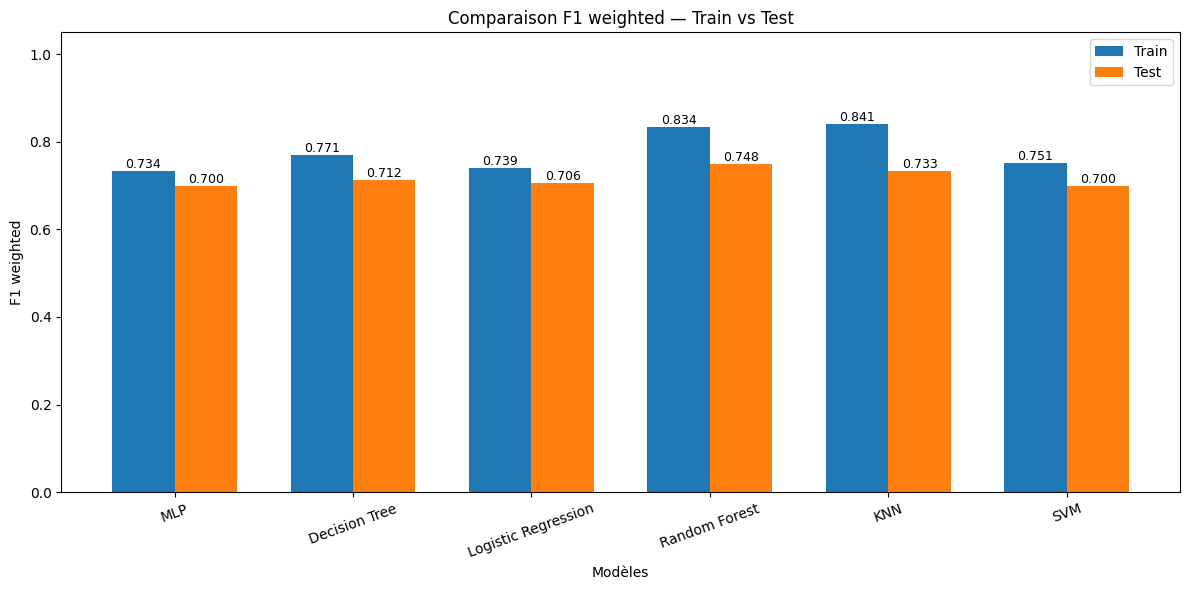

In [135]:
models = {
    "MLP": best_model_mlp,
    "Decision Tree": best_model_dt,
    "Logistic Regression": best_model_log,
    "Random Forest": best_model_rf,
    "KNN": best_model_knn,
    "SVM": best_model_svm
}

plot_f1_weighted_train_test(models, X_train_sel, y_train, X_test_sel, y_test)

In [136]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
stack = StackingClassifier(
    estimators=[
        ('rf', best_model_rf),
        ('knn', best_model_knn),
        ('mlp', best_model_mlp)
    ],
    final_estimator=LogisticRegression()
)
stack.fit(X_train_sel, y_train)

,estimators,"[('rf', ...), ('knn', ...), ...]"
,final_estimator,LogisticRegression()
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2


In [137]:
models={
    'rf': best_model_rf,
    'knn': best_model_knn,
    'mlp': best_model_mlp
}

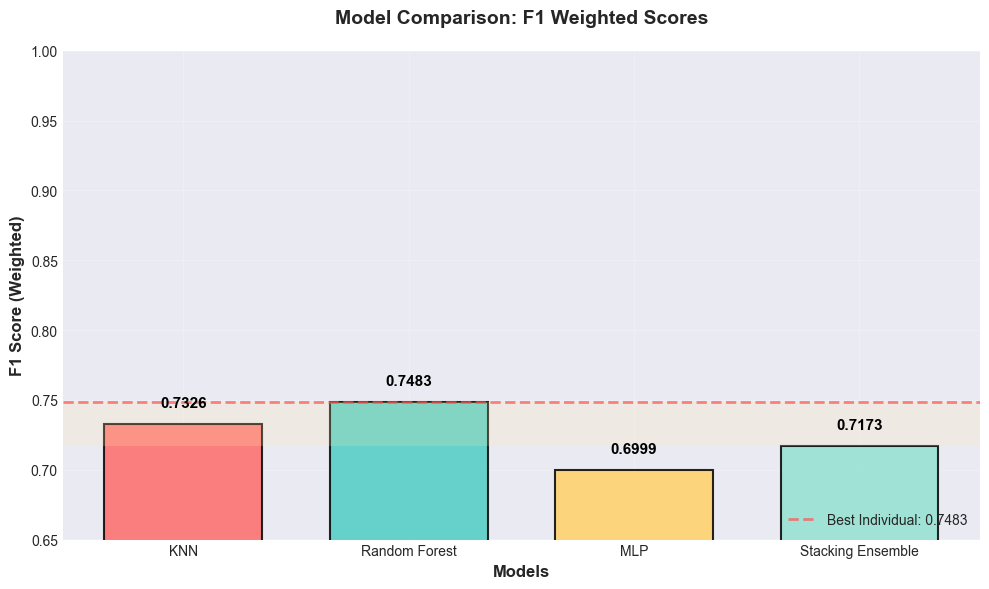


F1 WEIGHTED SCORES COMPARISON
  KNN                  : 0.7326
  Random Forest        : 0.7483 ★
  MLP                  : 0.6999
  Stacking Ensemble    : 0.7173

Best Individual Model  : 0.7483
Stacking Ensemble      : 0.7173
Improvement            : +-0.0310 (-4.14%)


In [138]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

# 1. Style moderne
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Calcul des F1 scores
model_names = ['KNN', 'Random Forest', 'MLP', 'Stacking Ensemble']
models_list = [models['knn'], models['rf'], models['mlp'], stack]

f1_scores = []
for model in models_list:
    y_pred = model.predict(X_test_sel)
    f1 = f1_score(y_test, y_pred, average='weighted')
    f1_scores.append(f1)

# 3. Palette de couleurs professionnelle
colors = ['#FF6B6B', '#4ECDC4', '#FFD166', '#95E1D3']

# 4. Graphique à barres avec effet 3D
bars = ax.bar(model_names, f1_scores, color=colors, edgecolor='black', 
              linewidth=1.5, alpha=0.85, width=0.7)

# 5. Ajout des valeurs sur les barres
for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{score:.4f}', ha='center', va='bottom', 
            fontsize=11, fontweight='bold', color='black')

# 6. Ligne du meilleur modèle individuel
best_individual = max(f1_scores[:3])
ax.axhline(y=best_individual, color='#FF5252', linestyle='--', 
           linewidth=2, alpha=0.7, label=f'Best Individual: {best_individual:.4f}')

# 7. Zone de fond pour highlight
ax.axhspan(best_individual, f1_scores[3], facecolor='#FFEAA7', alpha=0.2)

# 8. Personnalisation
ax.set_ylabel('F1 Score (Weighted)', fontsize=12, fontweight='bold')
ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison: F1 Weighted Scores', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim([min(f1_scores) - 0.05, 1.0])

# 9. Annotation du gain
gain = f1_scores[3] - best_individual
if gain > 0:
    ax.annotate(f'▲ +{gain:.4f}\n({(gain/best_individual*100):.1f}% improvement)', 
                xy=(3, f1_scores[3]), xytext=(3.1, f1_scores[3] - 0.08),
                arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
                fontsize=10, fontweight='bold', color='green',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#E8F5E9", edgecolor="green"))

# 10. Légende et grille
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# 11. Ajustement des ticks
plt.xticks(fontsize=10, rotation=0)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

# 12. Affichage texte propre
print("\n" + "="*60)
print("F1 WEIGHTED SCORES COMPARISON")
print("="*60)

for name, score in zip(model_names, f1_scores):
    stars = " ★" if score == max(f1_scores) else ""
    print(f"  {name:20} : {score:.4f}{stars}")

print("\n" + "="*60)
print(f"Best Individual Model  : {best_individual:.4f}")
print(f"Stacking Ensemble      : {f1_scores[3]:.4f}")
print(f"Improvement            : +{gain:.4f} ({(gain/best_individual*100):.2f}%)")
print("="*60)